**Heart Disease Uci**

**Task 3: Heart Disease Prediction
Objective:
Build a model to predict whether a person is at risk of heart disease based on their health data.
Dataset:
Heart Disease UCI Dataset (available on Kaggle)
Instructions:
● Clean the dataset (handle missing values if any).
● Perform Exploratory Data Analysis (EDA) to understand trends.
● Train a classification model (Logistic Regression or Decision Tree).
● Evaluate using metrics: accuracy, ROC curve, and confusion matrix.
● Highlight important features affecting prediction.
Skills:
● Binary classification
● Medical data understanding and interpretation
● Model evaluation using ROC-AUC and confusion matrix
● Feature importance analysis**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
dataset=pd.read_csv("HeartDiseaseTrain-Test.csv")

In [31]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [32]:
dataset.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

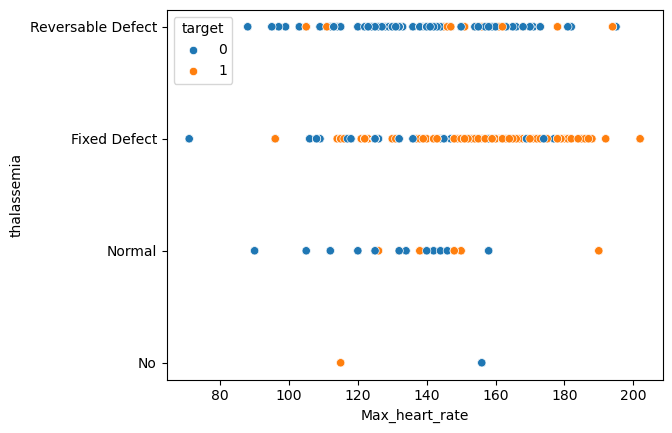

In [33]:
sns.scatterplot(x="Max_heart_rate",y="thalassemia",data=dataset,hue="target")
plt.show()

In [34]:
x=dataset.iloc[:,:-1]
plt.show()
x

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect


In [35]:
y=dataset.iloc[:,-1].values
y

array([0, 0, 0, ..., 0, 1, 0])

In [36]:
from sklearn.preprocessing import LabelEncoder
lbl_enc_x=LabelEncoder()
indexes=[1,5,8]
for i in indexes:
    x.iloc[:,i]=lbl_enc_x.fit_transform(x.iloc[:,i])
x

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,52,1,Typical angina,125,212,1,ST-T wave abnormality,168,0,1.0,Downsloping,Two,Reversable Defect
1,53,1,Typical angina,140,203,0,Normal,155,1,3.1,Upsloping,Zero,Reversable Defect
2,70,1,Typical angina,145,174,1,ST-T wave abnormality,125,1,2.6,Upsloping,Zero,Reversable Defect
3,61,1,Typical angina,148,203,1,ST-T wave abnormality,161,0,0.0,Downsloping,One,Reversable Defect
4,62,0,Typical angina,138,294,0,ST-T wave abnormality,106,0,1.9,Flat,Three,Fixed Defect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,Atypical angina,140,221,1,ST-T wave abnormality,164,1,0.0,Downsloping,Zero,Fixed Defect
1021,60,1,Typical angina,125,258,1,Normal,141,1,2.8,Flat,One,Reversable Defect
1022,47,1,Typical angina,110,275,1,Normal,118,1,1.0,Flat,One,Fixed Defect
1023,50,0,Typical angina,110,254,1,Normal,159,0,0.0,Downsloping,Zero,Fixed Defect


In [37]:
print(x["thalassemia"].unique())

['Reversable Defect' 'Fixed Defect' 'Normal' 'No']


In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(
                     transformers=[("encoder",OneHotEncoder(sparse_output=False),[2,6,10,11,12])],
                     remainder="passthrough"
                    )

x=ct.fit_transform(x)
x

array([[0.0, 0.0, 0.0, ..., 168, 0, 1.0],
       [0.0, 0.0, 0.0, ..., 155, 1, 3.1],
       [0.0, 0.0, 0.0, ..., 125, 1, 2.6],
       ...,
       [0.0, 0.0, 0.0, ..., 118, 1, 1.0],
       [0.0, 0.0, 0.0, ..., 159, 0, 0.0],
       [0.0, 0.0, 0.0, ..., 113, 0, 1.4]], dtype=object)

In [39]:
print(x)

[[0.0 0.0 0.0 ... 168 0 1.0]
 [0.0 0.0 0.0 ... 155 1 3.1]
 [0.0 0.0 0.0 ... 125 1 2.6]
 ...
 [0.0 0.0 0.0 ... 118 1 1.0]
 [0.0 0.0 0.0 ... 159 0 0.0]
 [0.0 0.0 0.0 ... 113 0 1.4]]


In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
x_train

array([[0.0, 0.0, 1.0, ..., 126, 0, 0.8],
       [0.0, 0.0, 0.0, ..., 154, 1, 0.0],
       [0.0, 0.0, 1.0, ..., 167, 0, 0.0],
       ...,
       [0.0, 0.0, 0.0, ..., 173, 1, 1.6],
       [0.0, 0.0, 0.0, ..., 161, 0, 0.0],
       [0.0, 0.0, 0.0, ..., 160, 0, 0.0]], dtype=object)

In [42]:
x_test

array([[0.0, 0.0, 0.0, ..., 163, 0, 0.0],
       [0.0, 0.0, 1.0, ..., 115, 0, 0.0],
       [0.0, 0.0, 0.0, ..., 145, 1, 0.8],
       ...,
       [0.0, 0.0, 1.0, ..., 169, 0, 0.0],
       [0.0, 0.0, 0.0, ..., 138, 1, 1.9],
       [0.0, 0.0, 1.0, ..., 165, 0, 2.5]], dtype=object)

In [43]:
y_test

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

In [44]:
y_train

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,

In [45]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [46]:
x_train

array([[-0.2934156 , -0.43008266,  1.6064825 , ..., -1.01909426,
        -0.72594894, -0.21066121],
       [-0.2934156 , -0.43008266, -0.62247799, ...,  0.20288215,
         1.37750735, -0.91215236],
       [-0.2934156 , -0.43008266,  1.6064825 , ...,  0.77022833,
        -0.72594894, -0.91215236],
       ...,
       [-0.2934156 , -0.43008266, -0.62247799, ...,  1.03208042,
         1.37750735,  0.49082993],
       [-0.2934156 , -0.43008266, -0.62247799, ...,  0.50837625,
        -0.72594894, -0.91215236],
       [-0.2934156 , -0.43008266, -0.62247799, ...,  0.46473423,
        -0.72594894, -0.91215236]])

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
dcl=RandomForestClassifier(n_estimators=100,criterion="entropy",random_state=42)
dcl.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [48]:
y_predict=dcl.predict(x_test)
y_predict

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

In [49]:
dcl.score(x_test,y_test)

0.9853658536585366

In [50]:
cm=confusion_matrix(y_test,y_predict)
cm

array([[102,   0],
       [  3, 100]])

In [51]:
accuracy=accuracy_score(y_test,y_predict)
print(f"Accuracy:{accuracy*100}%")

Accuracy:98.53658536585365%


In [52]:
from sklearn.metrics import mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)

In [53]:
mae

0.014634146341463415

In [54]:
r2

0.9414620217018846